In [43]:
import wave
import numpy as np
import matplotlib.pyplot as plt
import os
from scipy import signal
import numpy as np
import scipy.io.wavfile as wavfile
import pygame
from fft import fft


Bandstop Filter

rec/rec3.wav - sample_rate: 16000 - num_channels: 1 - sample_width: 2


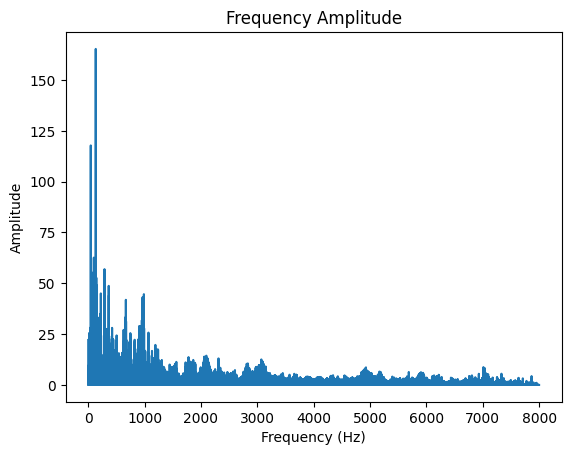

filtered_audio.wav - sample_rate: 16000 - num_channels: 1 - sample_width: 2


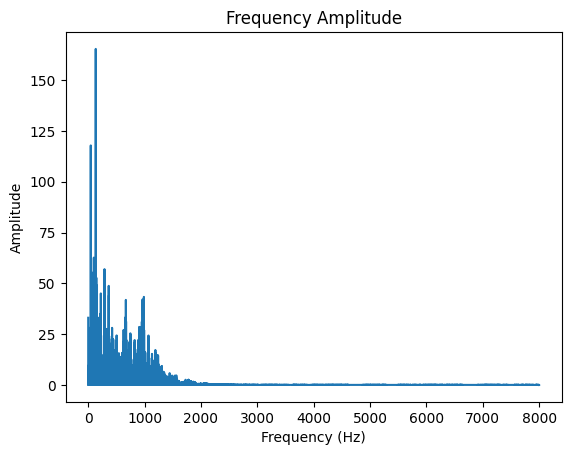

In [43]:
import numpy as np
from scipy import signal
import librosa
import soundfile as sf

FILE = 'rec/rec3.wav'

# Load the audio file
audio_file, sr = librosa.load(FILE, sr=16000)

# Define the frequency range to remove (in Hz)
f_low = 1500
f_high = 7999

# Create a bandstop filter with the desired frequency range
nyquist = 0.5 * sr
f_low_norm = f_low / nyquist
f_high_norm = f_high / nyquist
b, a = signal.butter(4, [f_low_norm, f_high_norm], btype='bandstop')

# Apply the filter to the audio signal
audio_filtered = signal.filtfilt(b, a, audio_file)

# Save the filtered audio file
sf.write('filtered_audio.wav', audio_filtered, 16000)

fft(FILE)
fft("filtered_audio.wav")


Bandpass Filter

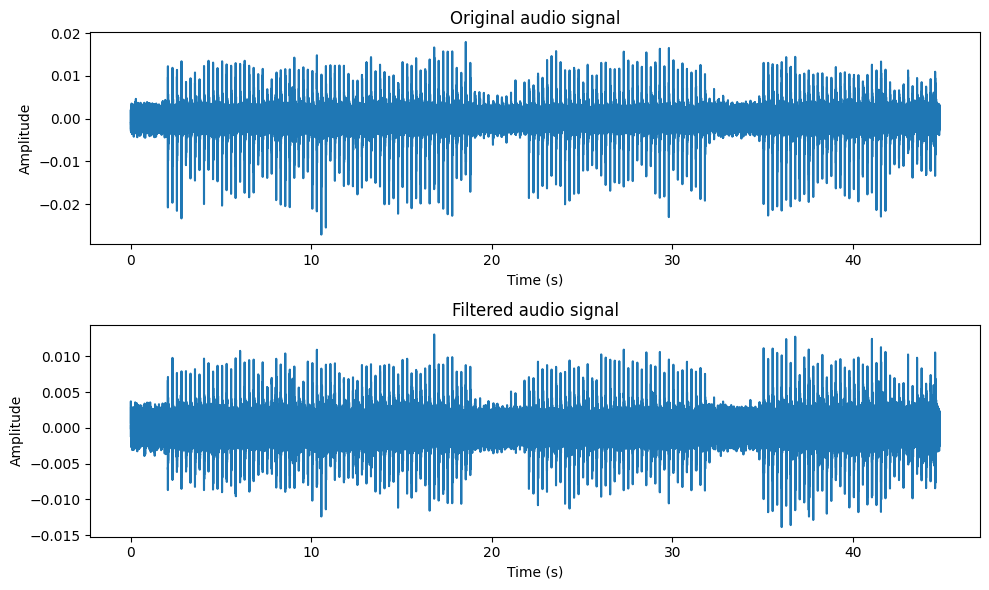

rec/rec3.wav - sample_rate: 16000 - num_channels: 1 - sample_width: 2


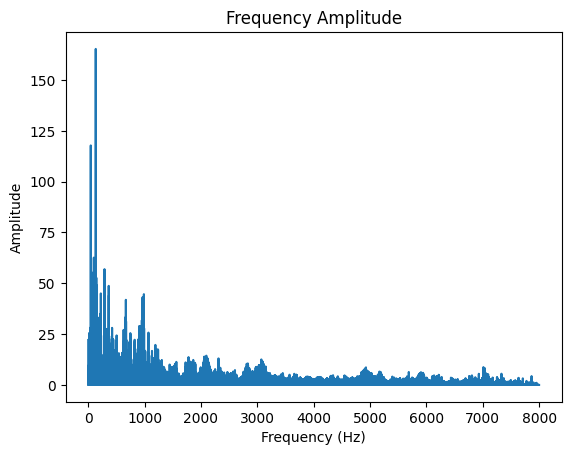

filtered_audio.wav - sample_rate: 16000 - num_channels: 1 - sample_width: 2


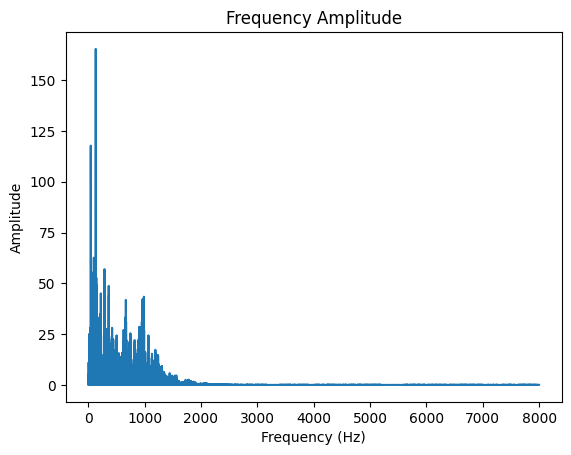

In [39]:
import numpy as np
from scipy import signal
import matplotlib.pyplot as plt
import librosa
import soundfile as sf

FILE = 'rec/rec3.wav'

# Load the audio file
audio_file, sr = librosa.load(FILE, sr=16000)

# Define the frequency range to keep (in Hz)
# f_high max 5500 everything after 6500 is only noise
f_low = 10
f_high = 1500

# Create a bandpass filter with the desired frequency range
nyquist = 0.5 * sr
f_low_norm = f_low / nyquist
f_high_norm = f_high / nyquist
b, a = signal.butter(4, [f_low_norm, f_high_norm], btype='band')

# Apply the filter to the audio signal
audio_filtered = signal.filtfilt(b, a, audio_file)

# Plot the original and filtered signals
t = np.arange(len(audio_file)) / sr
fig, ax = plt.subplots(2, 1, figsize=(10, 6))
ax[0].plot(t, audio_file)
ax[0].set_title('Original audio signal')
ax[0].set_xlabel('Time (s)')
ax[0].set_ylabel('Amplitude')
ax[1].plot(t, audio_filtered)
ax[1].set_title('Filtered audio signal')
ax[1].set_xlabel('Time (s)')
ax[1].set_ylabel('Amplitude')
plt.tight_layout()
plt.show()

# Save the filtered audio file
sf.write('filtered_audio.wav', audio_filtered, 16000)

fft(FILE)
fft("filtered_audio.wav")


Get loudest frequency in FTT

In [50]:
import numpy as np
import librosa

# Load the audio file
audio_file, sr = librosa.load('rec/rec3.wav', sr=16000)

# Compute the FFT of the audio signal
fft = np.abs(np.fft.rfft(audio_file))

# Find the frequencies with the highest amplitudes
freqs = np.fft.rfftfreq(len(audio_file), 1/sr)
rounded_freqs = np.round(freqs).astype(int)
unique_rounded_freqs = np.unique(rounded_freqs)
max_freqs = []
for freq in unique_rounded_freqs:
    if freq == 0:
        continue
    indices = np.where(rounded_freqs == freq)[0]
    max_index = indices[np.argmax(fft[indices])]
    max_freq = freqs[max_index]
    max_freqs.append(max_freq)

# Sort the frequencies by amplitude in descending order
max_freqs_sorted = sorted(max_freqs, key=lambda f: -fft[np.argmax(freqs == f)])

# Print the top 5 frequencies with the highest amplitudes
for i in range(5):
    freq = max_freqs_sorted[i]
    amp = fft[np.argmax(freqs == freq)]
    print(f'Top {i+1}: {freq:.1f} Hz (amplitude={amp:.2f})')


Top 1: 133.7 Hz (amplitude=165.32)
Top 2: 45.5 Hz (amplitude=117.84)
Top 3: 100.0 Hz (amplitude=62.64)
Top 4: 289.0 Hz (amplitude=56.97)
Top 5: 60.0 Hz (amplitude=55.45)
